In [ ]:
# =============================================================================
# AŞAMA 0 — KURULUM & VERİ HAZIRLAMA
# Google Colab'da ilk çalıştırılacak hücre.
# Drive'dan zip dosyasını çeker, /content/dataset/ altına açar.
# =============================================================================

# ---------- HÜCRE 0-A: Gerekli kütüphanelerin kurulumu ----------
# Colab'da varsayılan olarak bulunmayan kütüphaneleri yükleyelim
!pip install -q imbalanced-learn scikit-image

# ---------- HÜCRE 0-B: Google Drive bağlantısı ve zip açma ----------
"""
Google Drive'a yüklediğiniz zip dosyasının yolunu aşağıda belirtin.
Varsayılan olarak 'Skin Cancer MNIST HAM10000' adlı zip dosyası
Drive'ın kök dizininde olduğu varsayılmaktadır.
"""

import os
import zipfile
from google.colab import drive

# Drive'ı bağla
drive.mount('/content/drive')

# ─── KONFİGÜRASYON ───
# Drive'daki zip dosyasının yolunu buraya yazın:
ZIP_PATH = '/content/drive/MyDrive/Cilt Kanseri Projesi/Skin Cancer MNIST HAM10000.zip'
# Verilerin açılacağı hedef klasör:
DATASET_DIR = '/content/dataset'

# Hedef klasörü oluştur (yoksa)
os.makedirs(DATASET_DIR, exist_ok=True)

# Zip dosyasını aç
if not os.path.exists(os.path.join(DATASET_DIR, 'HAM10000_metadata.csv')):
    print(f"[INFO] Zip dosyası açılıyor: {ZIP_PATH}")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATASET_DIR)
    print("[OK] Zip başarıyla açıldı.")
else:
    print("[INFO] Veri seti zaten mevcut, tekrar açmaya gerek yok.")

# ---------- HÜCRE 0-C: Klasör yapısını doğrula ----------
# Beklenen dosyaları kontrol edelim
beklenen_dosyalar = [
    'HAM10000_metadata.csv',
    'hmnist_8_8_RGB.csv',
    'hmnist_28_28_L.csv',
    'HAM10000_images'
]

print("\n[KONTROL] Veri seti klasör yapısı:")
for dosya in beklenen_dosyalar:
    tam_yol = os.path.join(DATASET_DIR, dosya)
    if os.path.exists(tam_yol):
        if os.path.isdir(tam_yol):
            icerik = os.listdir(tam_yol)
            print(f"  ✅ {dosya}/ → {len(icerik)} dosya")
        else:
            boyut = os.path.getsize(tam_yol) / (1024 * 1024)  # MB
            print(f"  ✅ {dosya} → {boyut:.1f} MB")
    else:
        print(f"  ❌ {dosya} BULUNAMADI!")

# ---------- NOT ----------
# Eğer zip dosyasından çıkan klasör adı farklıysa (örneğin alt klasör varsa),
# dosya yollarını aşağıdaki şekilde düzeltmeniz gerekebilir:
#
# Örnek: Eğer zip içinde 'skin-cancer-mnist-ham10000' adlı bir alt klasör varsa:
# import shutil
# kaynak = os.path.join(DATASET_DIR, 'skin-cancer-mnist-ham10000')
# for item in os.listdir(kaynak):
#     shutil.move(os.path.join(kaynak, item), DATASET_DIR)

print("\n[BİLGİ] Aşama 0 tamamlandı. Aşama 1'e geçebilirsiniz.")


Mounted at /content/drive
[INFO] Zip dosyası açılıyor: /content/drive/MyDrive/Cilt Kanseri Projesi/Skin Cancer MNIST HAM10000.zip
[OK] Zip başarıyla açıldı.

[KONTROL] Veri seti klasör yapısı:
  ❌ HAM10000_metadata.csv BULUNAMADI!
  ❌ hmnist_8_8_RGB.csv BULUNAMADI!
  ❌ hmnist_28_28_L.csv BULUNAMADI!
  ❌ HAM10000_images BULUNAMADI!

[BİLGİ] Aşama 0 tamamlandı. Aşama 1'e geçebilirsiniz.


In [ ]:
import os
import shutil

hedef_dizin = '/content/dataset/'

# Alt klasörleri tarayıp metadata dosyasını bulalım
bulundu = False
for root, dirs, files in os.walk(hedef_dizin):
    if 'HAM10000_metadata.csv' in files:
        bulundu = True
        if root != hedef_dizin:
            print(f"GİZLİ KLASÖR BULUNDU: {root}")
            print("Dosyalar olması gereken ana dizine taşınıyor...")
            # İçindeki tüm dosyaları ana dizine taşı
            for item in os.listdir(root):
                kaynak_yol = os.path.join(root, item)
                hedef_yol = os.path.join(hedef_dizin, item)
                shutil.move(kaynak_yol, hedef_yol)
            print("✅ TAŞIMA BAŞARILI! Tüm dosyalar /content/dataset/ klasörüne alındı.")
        else:
            print("✅ Dosyalar zaten doğru dizinde!")
        break

if not bulundu:
    print("❌ DİKKAT: Zip dosyası hiç açılmamış veya eksik inmiş olabilir.")

GİZLİ KLASÖR BULUNDU: /content/dataset/Skin Cancer MNIST HAM10000
Dosyalar olması gereken ana dizine taşınıyor...
✅ TAŞIMA BAŞARILI! Tüm dosyalar /content/dataset/ klasörüne alındı.


In [ ]:
# =============================================================================
# AŞAMA 1 — VERİ BÖLME (StratifiedGroupKFold ile Hold-Out Split)
# =============================================================================
# Bu aşamada:
#   - HAM10000_metadata.csv okunur
#   - StratifiedGroupKFold(n_splits=6) ile 2 aşamalı bölme yapılır
#     → %70 train, %15 val, %15 test
#   - Tüm modellerde tutarlılık için indeksler .npy olarak kaydedilir
#   - image_path sütunu eklenir
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
import os

# ─── KONFİGÜRASYON ───
DATASET_DIR = '/content/dataset'
METADATA_PATH = os.path.join(DATASET_DIR, 'HAM10000_metadata.csv')
SPLIT_DIR = os.path.join(DATASET_DIR, 'splits')  # İndekslerin kaydedileceği klasör
os.makedirs(SPLIT_DIR, exist_ok=True)

# ─── Sabit sınıf etiket haritası (prompt'ta tanımlanan) ───
SINIF_HARITASI = {
    'akiec': 0,
    'bcc': 1,
    'bkl': 2,
    'df': 3,
    'mel': 4,
    'nv': 5,
    'vasc': 6
}
SINIF_ISIMLERI = list(SINIF_HARITASI.keys())  # Sıralı liste

# ═══════════════════════════════════════════════════════
# 1.1 — Metadata Dosyasını Oku
# ═══════════════════════════════════════════════════════
print("=" * 60)
print("AŞAMA 1: VERİ BÖLME")
print("=" * 60)

df_metadata = pd.read_csv(METADATA_PATH)
print(f"\n[INFO] Metadata yüklendi: {df_metadata.shape[0]} satır, {df_metadata.shape[1]} sütun")
print(f"[INFO] Sütunlar: {list(df_metadata.columns)}")

# ─── Sayısal etiket sütunu ekle ───
df_metadata['label'] = df_metadata['dx'].map(SINIF_HARITASI)

# Etiket dağılımını göster
print("\n[INFO] Sınıf dağılımı (dx):")
sinif_dagilimi = df_metadata['dx'].value_counts()
for sinif, sayi in sinif_dagilimi.items():
    oran = sayi / len(df_metadata) * 100
    print(f"  {sinif:>6s} (={SINIF_HARITASI[sinif]}): {sayi:>5d} örnek ({oran:5.1f}%)")

# ─── image_path sütunu ekle (DL modelleri için) ───
df_metadata['image_path'] = df_metadata['image_id'].apply(
    lambda x: f"/content/dataset/HAM10000_images/{x}.jpg"
)
print(f"\n[INFO] image_path sütunu eklendi. Örnek: {df_metadata['image_path'].iloc[0]}")

# ═══════════════════════════════════════════════════════
# 1.2 — StratifiedGroupKFold ile 2 Aşamalı Hold-Out Split
# ═══════════════════════════════════════════════════════
"""
NEDEN StratifiedGroupKFold?
─────────────────────────────
HAM10000 veri setinde aynı lesion_id'ye sahip birden fazla görüntü olabilir
(aynı lezyonun farklı açılardan çekilmiş fotoğrafları). Eğer aynı lezyona
ait görüntüler hem train hem test setine düşerse, model aslında "ezberleme"
yapar → data leakage oluşur.

StratifiedGroupKFold:
  - Stratified → Sınıf oranlarını korur (dengesiz veri setinde kritik)
  - Group → Aynı lesion_id'ye ait tüm görüntüler aynı fold'a düşer

2 Aşamalı Bölme Stratejisi:
  Aşama A: 6-fold → 1 fold test (%16.7), 5 fold geri kalan (%83.3)
  Aşama B: Kalan 5 fold'u tekrar 6-fold'a böl → 1 fold val (%~15), geri kalanı train (%~70)
  Sonuç: ~%70 train, ~%15 val, ~%15 test
"""

y = df_metadata['label'].values           # Stratifikasyon için etiketler
groups = df_metadata['lesion_id'].values   # Gruplama için lezyon ID'leri

# ─── AŞAMA A: Tüm veriyi test + geri_kalan olarak böl ───
print("\n[BÖLME] Aşama A: Test seti ayrılıyor...")
sgkf_1 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=42)

# İlk fold'u alalım: train_val_idx = geri kalan, test_idx = test seti
for train_val_idx, test_idx in sgkf_1.split(df_metadata, y, groups):
    break  # Sadece ilk fold'u kullanıyoruz

print(f"  Geri kalan: {len(train_val_idx)} örnek")
print(f"  Test seti:  {len(test_idx)} örnek")

# ─── AŞAMA B: Geri kalanı train + val olarak böl ───
print("\n[BÖLME] Aşama B: Train ve Val ayrılıyor...")
y_remaining = y[train_val_idx]
groups_remaining = groups[train_val_idx]

sgkf_2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=42)

# İlk fold'u alalım: train_sub_idx, val_sub_idx (geri kalanın içindeki indeksler)
for train_sub_idx, val_sub_idx in sgkf_2.split(
    df_metadata.iloc[train_val_idx], y_remaining, groups_remaining
):
    break

# Alt-indeksleri orijinal DataFrame indekslerine dönüştür
train_idx = train_val_idx[train_sub_idx]
val_idx = train_val_idx[val_sub_idx]

# ═══════════════════════════════════════════════════════
# 1.3 — Bölme Sonuçlarını Doğrula ve Kaydet
# ═══════════════════════════════════════════════════════

# ─── Boyut ve oran kontrolü ───
toplam = len(df_metadata)
print(f"\n{'='*60}")
print(f"BÖLME SONUÇLARI")
print(f"{'='*60}")
print(f"  Train: {len(train_idx):>5d} örnek ({len(train_idx)/toplam*100:.1f}%)")
print(f"  Val:   {len(val_idx):>5d} örnek ({len(val_idx)/toplam*100:.1f}%)")
print(f"  Test:  {len(test_idx):>5d} örnek ({len(test_idx)/toplam*100:.1f}%)")
print(f"  TOPLAM: {len(train_idx)+len(val_idx)+len(test_idx)} / {toplam}")

# ─── Kesişim kontrolü (data leakage yokluğunu doğrula) ───
assert len(np.intersect1d(train_idx, val_idx)) == 0, "HATA: Train ve Val kesişiyor!"
assert len(np.intersect1d(train_idx, test_idx)) == 0, "HATA: Train ve Test kesişiyor!"
assert len(np.intersect1d(val_idx, test_idx)) == 0, "HATA: Val ve Test kesişiyor!"
print("\n✅ Kesişim kontrolü BAŞARILI — Hiçbir indeks birden fazla sette yok.")

# ─── Grup (lesion_id) sızıntı kontrolü ───
train_groups = set(groups[train_idx])
val_groups = set(groups[val_idx])
test_groups = set(groups[test_idx])
assert len(train_groups & val_groups) == 0, "HATA: Aynı lesion_id train ve val'de!"
assert len(train_groups & test_groups) == 0, "HATA: Aynı lesion_id train ve test'te!"
assert len(val_groups & test_groups) == 0, "HATA: Aynı lesion_id val ve test'te!"
print("✅ Grup sızıntı kontrolü BAŞARILI — Aynı lezyon farklı setlere dağılmamış.")

# ─── Her setteki sınıf dağılımını göster ───
print(f"\n{'─'*60}")
print("Her setteki sınıf dağılımı (%):")
print(f"{'Sınıf':>8s} {'Train':>8s} {'Val':>8s} {'Test':>8s}")
print(f"{'─'*36}")
for sinif_adi, sinif_no in SINIF_HARITASI.items():
    t = np.sum(y[train_idx] == sinif_no) / len(train_idx) * 100
    v = np.sum(y[val_idx] == sinif_no) / len(val_idx) * 100
    te = np.sum(y[test_idx] == sinif_no) / len(test_idx) * 100
    print(f"  {sinif_adi:>6s}: {t:>6.1f}%  {v:>6.1f}%  {te:>6.1f}%")

# ─── İndeksleri .npy olarak kaydet ───
np.save(os.path.join(SPLIT_DIR, 'train_idx.npy'), train_idx)
np.save(os.path.join(SPLIT_DIR, 'val_idx.npy'), val_idx)
np.save(os.path.join(SPLIT_DIR, 'test_idx.npy'), test_idx)
print(f"\n✅ İndeksler kaydedildi: {SPLIT_DIR}/")
print(f"   train_idx.npy → {len(train_idx)} indeks")
print(f"   val_idx.npy   → {len(val_idx)} indeks")
print(f"   test_idx.npy  → {len(test_idx)} indeks")

# ─── Metadata'yı da güncellenmiş haliyle kaydet (opsiyonel) ───
df_metadata.to_csv(os.path.join(DATASET_DIR, 'HAM10000_metadata_processed.csv'), index=False)
print(f"\n✅ Güncellenmiş metadata kaydedildi: HAM10000_metadata_processed.csv")

print(f"\n{'='*60}")
print("AŞAMA 1 TAMAMLANDI — Aşama 2'ye geçebilirsiniz.")
print(f"{'='*60}")


AŞAMA 1: VERİ BÖLME

[INFO] Metadata yüklendi: 10015 satır, 7 sütun
[INFO] Sütunlar: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

[INFO] Sınıf dağılımı (dx):
      nv (=5):  6705 örnek ( 66.9%)
     mel (=4):  1113 örnek ( 11.1%)
     bkl (=2):  1099 örnek ( 11.0%)
     bcc (=1):   514 örnek (  5.1%)
   akiec (=0):   327 örnek (  3.3%)
    vasc (=6):   142 örnek (  1.4%)
      df (=3):   115 örnek (  1.1%)

[INFO] image_path sütunu eklendi. Örnek: /content/dataset/HAM10000_images/ISIC_0027419.jpg

[BÖLME] Aşama A: Test seti ayrılıyor...
  Geri kalan: 8365 örnek
  Test seti:  1650 örnek

[BÖLME] Aşama B: Train ve Val ayrılıyor...

BÖLME SONUÇLARI
  Train:  6970 örnek (69.6%)
  Val:    1395 örnek (13.9%)
  Test:   1650 örnek (16.5%)
  TOPLAM: 10015 / 10015

✅ Kesişim kontrolü BAŞARILI — Hiçbir indeks birden fazla sette yok.
✅ Grup sızıntı kontrolü BAŞARILI — Aynı lezyon farklı setlere dağılmamış.

────────────────────────────────────────────────────────────
H

In [ ]:
# =============================================================================
# AŞAMA 2 — BASELINE ML MODELLERİ (k-NN ve SVM)
# =============================================================================

import numpy as np
import pandas as pd
import os
import time
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from skimage.feature import hog
from imblearn.over_sampling import SMOTE

DATASET_DIR = '/content/dataset'
SPLIT_DIR = os.path.join(DATASET_DIR, 'splits')
SINIF_ISIMLERI = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

print("=" * 60)
print("AŞAMA 2: BASELINE ML MODELLERİ")
print("=" * 60)

train_idx = np.load(os.path.join(SPLIT_DIR, 'train_idx.npy'))
val_idx = np.load(os.path.join(SPLIT_DIR, 'val_idx.npy'))
test_idx = np.load(os.path.join(SPLIT_DIR, 'test_idx.npy'))

print(f"\n[INFO] İndeksler yüklendi:")
print(f"  Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

# DOĞRU ETİKETLERİ METADATA'DAN ALMA (HAYAT KURTARAN DÜZELTME)
df_meta_dogru = pd.read_csv(os.path.join(DATASET_DIR, 'HAM10000_metadata.csv'))
SINIF_HARITASI = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
y_dogru_etiketler = df_meta_dogru['dx'].map(SINIF_HARITASI).values

# ---------------------------------------------------------
# 2.1 — k-NN MODELİ
# ---------------------------------------------------------
print(f"\n{'─'*60}")
print("2.1 — k-NN MODELİ")
print(f"{'─'*60}")

print("\n[1/5] hmnist_8_8_RGB.csv okunuyor...")
df_knn = pd.read_csv(os.path.join(DATASET_DIR, 'hmnist_8_8_RGB.csv'))

# Piksel verileri CSV'den, etiketler Metadata'dan!
X_knn_all = df_knn.iloc[:, :-1].values.astype(np.float32)
y_knn_all = y_dogru_etiketler

X_knn_train = X_knn_all[train_idx]
y_knn_train = y_knn_all[train_idx]
X_knn_val = X_knn_all[val_idx]
y_knn_val = y_knn_all[val_idx]
X_knn_test = X_knn_all[test_idx]
y_knn_test = y_knn_all[test_idx]

print(f"\n[3/5] PCA(n_components=32) uygulanıyor...")
pca_knn = PCA(n_components=32, random_state=42)
X_knn_train_pca = pca_knn.fit_transform(X_knn_train)
X_knn_val_pca = pca_knn.transform(X_knn_val)
X_knn_test_pca = pca_knn.transform(X_knn_test)

print("\n[4/5] SMOTE uygulanıyor (sadece eğitim verisi)...")
smote = SMOTE(random_state=42)
X_knn_train_resampled, y_knn_train_resampled = smote.fit_resample(X_knn_train_pca, y_knn_train)

print("\n[5/5] KNeighborsClassifier(n_neighbors=5) eğitiliyor...")
baslangic = time.time()
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_knn_train_resampled, y_knn_train_resampled)
sure = time.time() - baslangic
print(f"  Eğitim süresi: {sure:.1f} saniye")

print(f"\n{'─'*40}")
print("k-NN SONUÇLARI (Test Seti)")
print(f"{'─'*40}")
y_knn_pred = knn_model.predict(X_knn_test_pca)
knn_f1_macro = f1_score(y_knn_test, y_knn_pred, average='macro')
print(f"\n  Macro F1 Score: {knn_f1_macro:.4f}")
print(classification_report(y_knn_test, y_knn_pred, target_names=SINIF_ISIMLERI, digits=4))

y_knn_val_pred = knn_model.predict(X_knn_val_pca)
knn_val_f1 = f1_score(y_knn_val, y_knn_val_pred, average='macro')

# ---------------------------------------------------------
# 2.2 — SVM MODELİ (HOG + PCA + SVC)
# ---------------------------------------------------------
print(f"\n{'─'*60}")
print("2.2 — SVM MODELİ (HOG + PCA)")
print(f"{'─'*60}")

print("\n[1/6] hmnist_28_28_L.csv okunuyor...")
df_svm = pd.read_csv(os.path.join(DATASET_DIR, 'hmnist_28_28_L.csv'))

# Piksel verileri CSV'den, etiketler Metadata'dan!
X_svm_all = df_svm.iloc[:, :-1].values.astype(np.float32)
y_svm_all = y_dogru_etiketler

X_svm_train = X_svm_all[train_idx]
y_svm_train = y_svm_all[train_idx]
X_svm_val = X_svm_all[val_idx]
y_svm_val = y_svm_all[val_idx]
X_svm_test = X_svm_all[test_idx]
y_svm_test = y_svm_all[test_idx]

print("\n[3/6] Pikseller 28×28 görüntüye dönüştürülüyor...")
X_svm_train_2d = X_svm_train.reshape(-1, 28, 28)
X_svm_val_2d = X_svm_val.reshape(-1, 28, 28)
X_svm_test_2d = X_svm_test.reshape(-1, 28, 28)

print("\n[4/6] HOG özellikleri çıkarılıyor...")
def hog_ozellik_cikar(goruntu_dizisi):
    ozellikler = []
    for i, img in enumerate(goruntu_dizisi):
        feat = hog(img, orientations=9, pixels_per_cell=(7, 7), cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True)
        ozellikler.append(feat)
        if (i + 1) % 2000 == 0:
            print(f"    {i+1}/{len(goruntu_dizisi)} işlendi...")
    return np.array(ozellikler, dtype=np.float32)

baslangic = time.time()
X_svm_train_hog = hog_ozellik_cikar(X_svm_train_2d)
X_svm_val_hog = hog_ozellik_cikar(X_svm_val_2d)
X_svm_test_hog = hog_ozellik_cikar(X_svm_test_2d)
print(f"  HOG süresi: {time.time() - baslangic:.1f} saniye")

print("\n[5/6] PCA(n_components=128) uygulanıyor...")
pca_svm = PCA(n_components=128, random_state=42)
X_svm_train_pca = pca_svm.fit_transform(X_svm_train_hog)
X_svm_val_pca = pca_svm.transform(X_svm_val_hog)
X_svm_test_pca = pca_svm.transform(X_svm_test_hog)

print("\n[6/6] SVC(kernel='rbf', class_weight='balanced') eğitiliyor...")
baslangic = time.time()
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42, decision_function_shape='ovr')
svm_model.fit(X_svm_train_pca, y_svm_train)
print(f"  Eğitim süresi: {time.time() - baslangic:.1f} saniye")

print(f"\n{'─'*40}")
print("SVM SONUÇLARI (Test Seti)")
print(f"{'─'*40}")
y_svm_pred = svm_model.predict(X_svm_test_pca)
svm_f1_macro = f1_score(y_svm_test, y_svm_pred, average='macro')
print(f"\n  Macro F1 Score: {svm_f1_macro:.4f}")
print(classification_report(y_svm_test, y_svm_pred, target_names=SINIF_ISIMLERI, digits=4))

y_svm_val_pred = svm_model.predict(X_svm_val_pca)
svm_val_f1 = f1_score(y_svm_val, y_svm_val_pred, average='macro')

print(f"\n{'='*60}")
print("BASELINE MODEL KARŞILAŞTIRMASI")
print(f"{'='*60}")
print(f"{'Model':<15s} {'Val F1':>10s} {'Test F1':>10s}")
print(f"{'─'*37}")
print(f"{'k-NN':<15s} {knn_val_f1:>10.4f} {knn_f1_macro:>10.4f}")
print(f"{'SVM (HOG)':<15s} {svm_val_f1:>10.4f} {svm_f1_macro:>10.4f}")
print(f"{'─'*37}")

AŞAMA 2: BASELINE ML MODELLERİ

[INFO] İndeksler yüklendi:
  Train: 6970, Val: 1395, Test: 1650

────────────────────────────────────────────────────────────
2.1 — k-NN MODELİ
────────────────────────────────────────────────────────────

[1/5] hmnist_8_8_RGB.csv okunuyor...

[3/5] PCA(n_components=32) uygulanıyor...

[4/5] SMOTE uygulanıyor (sadece eğitim verisi)...

[5/5] KNeighborsClassifier(n_neighbors=5) eğitiliyor...
  Eğitim süresi: 0.0 saniye

────────────────────────────────────────
k-NN SONUÇLARI (Test Seti)
────────────────────────────────────────

  Macro F1 Score: 0.3031
              precision    recall  f1-score   support

       akiec     0.0972    0.1707    0.1239        41
         bcc     0.2083    0.3529    0.2620        85
         bkl     0.2526    0.3967    0.3087       184
          df     0.1600    0.4444    0.2353        27
         mel     0.2901    0.4064    0.3385       187
          nv     0.9197    0.5915    0.7200      1104
        vasc     0.0816    0.36

[INFO] Cihaz: cuda
  GPU: Tesla T4
  Bellek: 15.6 GB
AŞAMA 3: TRANSFER LEARNING (PyTorch)
[INFO] Metadata: 10015 örnek
[INFO] Train: 6970, Val: 1395, Test: 1650

████████████████████████████████████████████████████████████
█  ALEXNET EĞİTİMİ
████████████████████████████████████████████████████████████

EĞİTİM BAŞLIYOR: ALEXNET | Aug=ON | CW=ON

[DATA] Train: 6970 örnek, 218 batch
[DATA] Val: 1395 örnek, 44 batch

[MODEL] ALEXNET oluşturuluyor...
  Dondurulan: features (tüm conv)
  Eğitilen:   classifier
  Toplam parametre:       57,032,519
  Eğitilebilir:           54,562,823 (95.7%)
  Dondurulmuş:             2,469,696 (4.3%)

[INFO] Sınıf ağırlıkları (balanced):
   akiec (0): 4.2919
     bcc (1): 2.8207
     bkl (2): 1.2848
      df (3): 13.8294
     mel (4): 1.2652
      nv (5): 0.2142
    vasc (6): 9.6671
[LOSS] CrossEntropyLoss(weight=balanced)
[OPTIM] Adam(lr=0.0001)

────────────────────────────────────────────────────────────
Epoch | Train Loss  Train Acc |   Val Loss    Val Ac

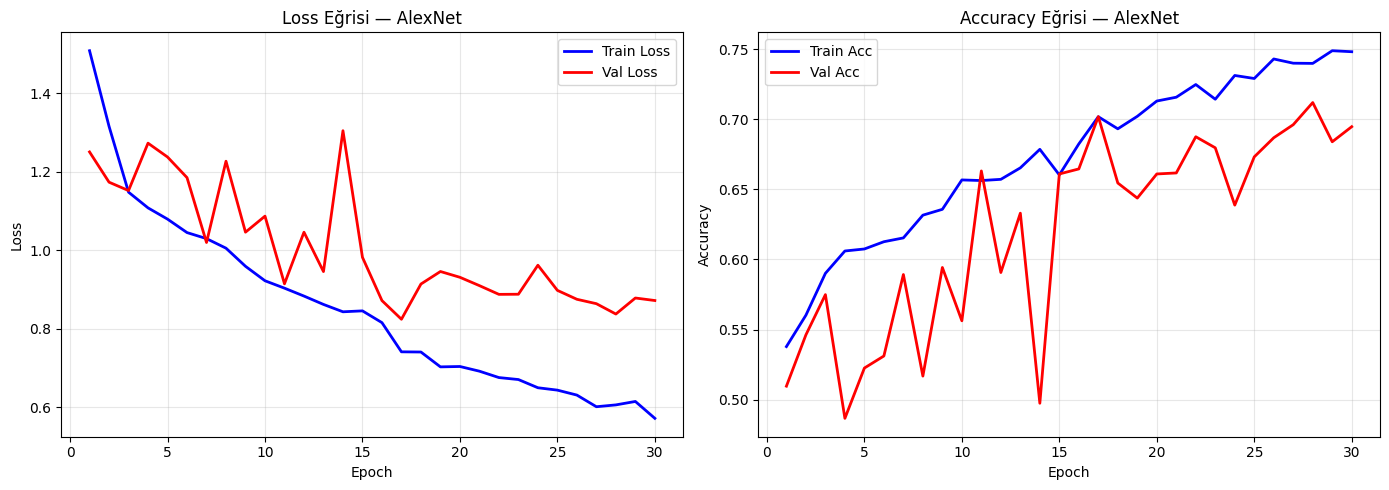


████████████████████████████████████████████████████████████
█  VGG16 EĞİTİMİ
████████████████████████████████████████████████████████████

EĞİTİM BAŞLIYOR: VGG16 | Aug=ON | CW=ON

[DATA] Train: 6970 örnek, 218 batch
[DATA] Val: 1395 örnek, 44 batch

[MODEL] VGG16 oluşturuluyor...
  Dondurulan: features[0:24]
  Eğitilen:   features[24:] + classifier
  Toplam parametre:      134,289,223
  Eğitilebilir:          126,653,959 (94.3%)
  Dondurulmuş:             7,635,264 (5.7%)

[INFO] Sınıf ağırlıkları (balanced):
   akiec (0): 4.2919
     bcc (1): 2.8207
     bkl (2): 1.2848
      df (3): 13.8294
     mel (4): 1.2652
      nv (5): 0.2142
    vasc (6): 9.6671
[LOSS] CrossEntropyLoss(weight=balanced)
[OPTIM] Adam(lr=0.0001)

────────────────────────────────────────────────────────────
Epoch | Train Loss  Train Acc |   Val Loss    Val Acc |         LR | Durum
────────────────────────────────────────────────────────────
    1   |     1.5336     0.5772 |     1.2473     0.5190 |   1.00e-04 | ✅

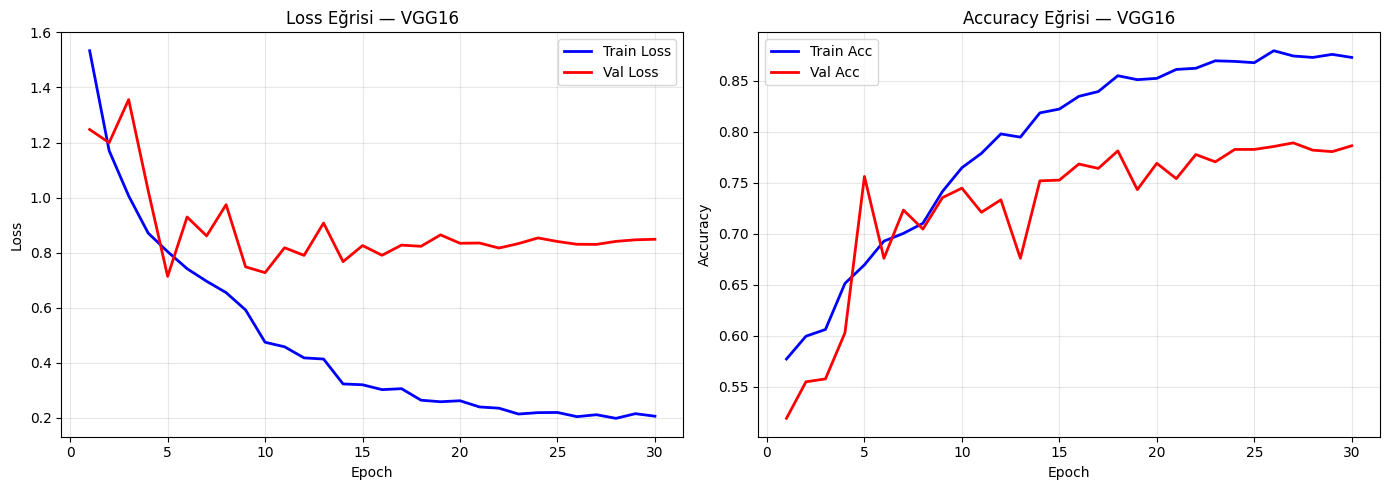


████████████████████████████████████████████████████████████
█  RESNET50 EĞİTİMİ
████████████████████████████████████████████████████████████

EĞİTİM BAŞLIYOR: RESNET50 | Aug=ON | CW=ON

[DATA] Train: 6970 örnek, 218 batch
[DATA] Val: 1395 örnek, 44 batch

[MODEL] RESNET50 oluşturuluyor...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


  Dondurulan: conv1 + bn1 + layer1 + layer2
  Eğitilen:   layer3 + layer4 + fc
  Toplam parametre:       23,522,375
  Eğitilebilir:           22,077,447 (93.9%)
  Dondurulmuş:             1,444,928 (6.1%)

[INFO] Sınıf ağırlıkları (balanced):
   akiec (0): 4.2919
     bcc (1): 2.8207
     bkl (2): 1.2848
      df (3): 13.8294
     mel (4): 1.2652
      nv (5): 0.2142
    vasc (6): 9.6671
[LOSS] CrossEntropyLoss(weight=balanced)
[OPTIM] Adam(lr=0.0001)

────────────────────────────────────────────────────────────
Epoch | Train Loss  Train Acc |   Val Loss    Val Acc |         LR | Durum
────────────────────────────────────────────────────────────
    1   |     1.1659     0.6003 |     0.9138     0.6688 |   1.00e-04 | ✅ Checkpoint (acc=0.6688)
    2   |     0.8217     0.6879 |     0.9770     0.6573 |   1.00e-04 | (83s)
    3   |     0.6469     0.7392 |     0.7558     0.7161 |   1.00e-04 | ✅ Checkpoint (acc=0.7161)
    4   |     0.6029     0.7624 |     0.8604     0.7491 |   1.00e-04 | ✅ Ch

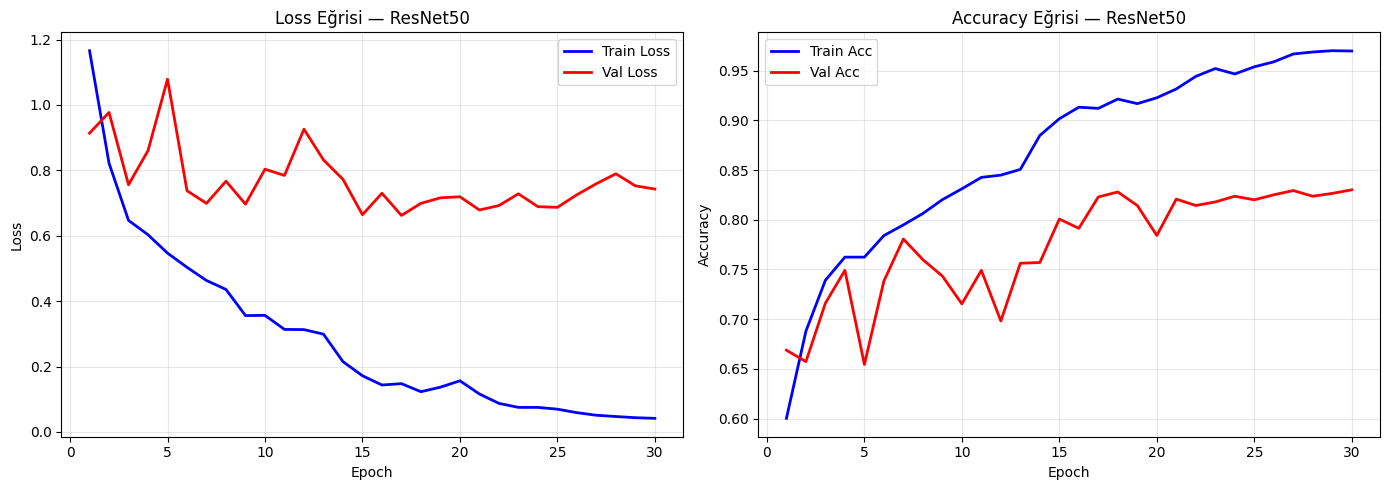


AŞAMA 3 TAMAMLANDI — Aşama 4'e geçebilirsiniz.


In [ ]:
# =============================================================================
# AŞAMA 3 — TRANSFER LEARNING (PyTorch)
# =============================================================================
# Bu aşamada:
#   - AlexNet, VGG16, ResNet50 transfer learning modelleri
#   - Orijinal .jpg görüntüler PyTorch Dataset ile okunur (CSV KULLANILMAZ)
#   - Augmentation sadece train'e, Normalize her sete
#   - class_weight → CrossEntropyLoss(weight=...)
#   - Manuel eğitim döngüsü: EarlyStopping + ReduceLROnPlateau + Checkpoint
#   - Ablasyon için parametrik: train_model(use_aug=True, use_cw=True)
# =============================================================================

import numpy as np
import pandas as pd
import os
import time
import copy
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.utils.class_weight import compute_class_weight

# ─── GPU kontrolü ───
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Cihaz: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Bellek: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ─── KONFİGÜRASYON ───
DATASET_DIR = '/content/dataset'
SPLIT_DIR = os.path.join(DATASET_DIR, 'splits')
MODEL_DIR = os.path.join(DATASET_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

SINIF_ISIMLERI = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
NUM_CLASSES = 7

# Eğitim hiperparametreleri
BATCH_SIZE = 32
MAX_EPOCHS = 50
LR = 1e-4
PATIENCE_ES = 10       # EarlyStopping: kaç epoch iyileşme olmazsa dur
PATIENCE_LR = 4       # ReduceLROnPlateau: kaç epoch iyileşme olmazsa lr düşür
LR_FACTOR = 0.5       # Öğrenme oranı düşürme faktörü

# ImageNet normalizasyon değerleri
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# ═══════════════════════════════════════════════════════
# 3.0 — Veri Yükleme
# ═══════════════════════════════════════════════════════
print("=" * 60)
print("AŞAMA 3: TRANSFER LEARNING (PyTorch)")
print("=" * 60)

# İndeksleri yükle
train_idx = np.load(os.path.join(SPLIT_DIR, 'train_idx.npy'))
val_idx = np.load(os.path.join(SPLIT_DIR, 'val_idx.npy'))
test_idx = np.load(os.path.join(SPLIT_DIR, 'test_idx.npy'))

# Metadata yükle
df_metadata = pd.read_csv(os.path.join(DATASET_DIR, 'HAM10000_metadata.csv'))

# Sınıf etiket haritası
SINIF_HARITASI = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
df_metadata['label'] = df_metadata['dx'].map(SINIF_HARITASI)
df_metadata['image_path'] = df_metadata['image_id'].apply(
    lambda x: f"/content/dataset/HAM10000_images/{x}.jpg"
)

print(f"[INFO] Metadata: {len(df_metadata)} örnek")
print(f"[INFO] Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")


# ═══════════════════════════════════════════════════════
# 3.1 — PyTorch Dataset Sınıfı
# ═══════════════════════════════════════════════════════
class HAMDataset(Dataset):
    """
    HAM10000 veri seti için özel PyTorch Dataset sınıfı.
    Orijinal .jpg dosyalarını diskten okur.

    Args:
        df: Metadata DataFrame (image_path ve label sütunları olmalı)
        transform: Uygulanacak dönüşümler (augmentation + normalize)
    """
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Görüntüyü oku
        img_path = self.df.loc[idx, 'image_path']
        image = Image.open(img_path).convert('RGB')

        # Etiketi al
        label = self.df.loc[idx, 'label']

        # Dönüşümleri uygula
        if self.transform:
            image = self.transform(image)

        return image, label


# ═══════════════════════════════════════════════════════
# 3.2 — Dönüşümler (Transforms)
# ═══════════════════════════════════════════════════════
def get_transforms(use_aug=True):
    """
    Eğitim ve değerlendirme dönüşümlerini döndürür.

    Args:
        use_aug: True ise eğitim setine augmentation uygulanır

    Returns:
        train_transform, eval_transform
    """
    # ─── Eğitim seti dönüşümleri ───
    if use_aug:
        train_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),      # Yatay çevirme
            transforms.RandomVerticalFlip(),         # Dikey çevirme
            transforms.RandomRotation(30),           # ±30° döndürme
            transforms.ColorJitter(brightness=0.2),  # Parlaklık değişimi
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        ])
    else:
        # Augmentation kapalı → sadece resize + normalize
        train_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        ])

    # ─── Val/Test dönüşümleri (augmentation YOK) ───
    eval_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    return train_transform, eval_transform


# ═══════════════════════════════════════════════════════
# 3.3 — Sınıf Ağırlıkları (Class Weights)
# ═══════════════════════════════════════════════════════
def compute_class_weights(y_train):
    """
    Dengesiz sınıf dağılımını telafi etmek için ağırlıkları hesaplar.

    compute_class_weight('balanced') formülü:
        w_c = n_samples / (n_classes * n_samples_c)

    Azınlık sınıflarına (df, vasc) yüksek, çoğunluk sınıflarına (nv) düşük ağırlık verir.
    """
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)

    print("\n[INFO] Sınıf ağırlıkları (balanced):")
    for sinif_no, agirlik in zip(classes, weights):
        print(f"  {SINIF_ISIMLERI[sinif_no]:>6s} ({sinif_no}): {agirlik:.4f}")

    return torch.FloatTensor(weights).to(device)


# ═══════════════════════════════════════════════════════
# 3.4 — Model Oluşturma (build_model)
# ═══════════════════════════════════════════════════════
def build_model(arch):
    """
    Transfer learning modeli oluşturur.

    Args:
        arch: 'alexnet', 'vgg16', veya 'resnet50'

    Returns:
        model: Belirtilen mimariye göre yapılandırılmış model

    Dondurma stratejisi:
        - AlexNet: Tüm conv katmanları dondur, sadece classifier eğit
        - VGG16: features[0:24] dondur, features[24:] + classifier eğit
        - ResNet50: layer1+layer2 dondur, layer3+layer4+fc eğit
    """
    print(f"\n[MODEL] {arch.upper()} oluşturuluyor...")

    if arch == 'alexnet':
        model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

        # Tüm conv (features) katmanlarını dondur
        for param in model.features.parameters():
            param.requires_grad = False

        # Classifier'ı yeniden tasarla (son katman 7 sınıfa)
        model.classifier[-1] = nn.Linear(
            model.classifier[-1].in_features, NUM_CLASSES
        )

        dondurulan = "features (tüm conv)"
        egitilen = "classifier"

    elif arch == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # features[0:24] dondur (ilk 24 katman)
        for i, layer in enumerate(model.features):
            if i < 24:
                for param in layer.parameters():
                    param.requires_grad = False

        # Classifier'ı yeniden tasarla
        model.classifier[-1] = nn.Linear(
            model.classifier[-1].in_features, NUM_CLASSES
        )

        dondurulan = "features[0:24]"
        egitilen = "features[24:] + classifier"

    elif arch == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # layer1 ve layer2 dondur
        for param in model.conv1.parameters():
            param.requires_grad = False
        for param in model.bn1.parameters():
            param.requires_grad = False
        for param in model.layer1.parameters():
            param.requires_grad = False
        for param in model.layer2.parameters():
            param.requires_grad = False

        # FC katmanını yeniden tasarla
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

        dondurulan = "conv1 + bn1 + layer1 + layer2"
        egitilen = "layer3 + layer4 + fc"

    else:
        raise ValueError(f"Desteklenmeyen mimari: {arch}")

    # Eğitilebilir parametre sayısını hesapla
    toplam_param = sum(p.numel() for p in model.parameters())
    egitilen_param = sum(p.numel() for p in model.parameters() if p.requires_grad)
    dondurulan_param = toplam_param - egitilen_param

    print(f"  Dondurulan: {dondurulan}")
    print(f"  Eğitilen:   {egitilen}")
    print(f"  Toplam parametre:     {toplam_param:>12,}")
    print(f"  Eğitilebilir:         {egitilen_param:>12,} ({egitilen_param/toplam_param*100:.1f}%)")
    print(f"  Dondurulmuş:          {dondurulan_param:>12,} ({dondurulan_param/toplam_param*100:.1f}%)")

    model = model.to(device)
    return model


# ═══════════════════════════════════════════════════════
# 3.5 — Eğitim Döngüsü (Manuel — Parametrik Ablasyon)
# ═══════════════════════════════════════════════════════
def train_model(model_or_arch, use_aug=True, use_cw=True):
    """
    Transfer learning modelini eğitir.

    ABLASYON TASARIMI:
    ─────────────────
    Bu fonksiyon parametrik olarak tasarlanmıştır:
        use_aug=True  → Eğitim setine veri artırma (augmentation) uygula
        use_cw=True   → CrossEntropyLoss'a sınıf ağırlığı (class weight) ver

    Ablasyon Deneyleri (ResNet50 üzerinde):
        1. train_model('resnet50', use_aug=False, use_cw=False) → İkisi de yok
        2. train_model('resnet50', use_aug=True,  use_cw=False) → Sadece Aug
        3. train_model('resnet50', use_aug=False, use_cw=True)  → Sadece CW
        4. train_model('resnet50', use_aug=True,  use_cw=True)  → İkisi de var

    Manuel Callback'ler:
        - EarlyStopping: val_loss 5 epoch iyileşmezse dur
        - ReduceLROnPlateau: val_loss 3 epoch iyileşmezse lr *= 0.5
        - Checkpoint: val_accuracy en yüksek olduğunda ağırlıkları kaydet

    Args:
        model_or_arch: Mimari adı ('alexnet', 'vgg16', 'resnet50') veya
                       bu isimlerden biri. Her çağrıda model sıfırdan oluşturulur.
        use_aug: Veri artırma kullan (bool)
        use_cw: Sınıf ağırlığı kullan (bool)

    Returns:
        model: En iyi ağırlıklarla yüklenmiş model
        history: Eğitim geçmişi dict'i
    """
    # Mimari adını belirle (string veya nn.Module kabul eder)
    if isinstance(model_or_arch, str):
        arch = model_or_arch
    else:
        # Eğer model nesnesi verilmişse, sınıf adından mimariyi tahmin et
        class_name = model_or_arch.__class__.__name__.lower()
        if 'alexnet' in class_name:
            arch = 'alexnet'
        elif 'vgg' in class_name:
            arch = 'vgg16'
        elif 'resnet' in class_name:
            arch = 'resnet50'
        else:
            raise ValueError(f"Tanınmayan model sınıfı: {class_name}")
    # NOT: Her çağrıda model sıfırdan (pretrained) oluşturulur,
    # böylece önceki eğitimin ağırlıkları ablasyon sonuçlarını etkilemez.
    print(f"\n{'='*60}")
    deney_adi = f"{arch.upper()} | Aug={'ON' if use_aug else 'OFF'} | CW={'ON' if use_cw else 'OFF'}"
    print(f"EĞİTİM BAŞLIYOR: {deney_adi}")
    print(f"{'='*60}")

    # ─── 1. Dönüşümleri hazırla ───
    train_transform, eval_transform = get_transforms(use_aug=use_aug)

    # ─── 2. Dataset ve DataLoader oluştur ───
    df_train = df_metadata.iloc[train_idx].copy()
    df_val = df_metadata.iloc[val_idx].copy()

    train_dataset = HAMDataset(df_train, transform=train_transform)
    val_dataset = HAMDataset(df_val, transform=eval_transform)

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=True
    )

    print(f"\n[DATA] Train: {len(train_dataset)} örnek, {len(train_loader)} batch")
    print(f"[DATA] Val: {len(val_dataset)} örnek, {len(val_loader)} batch")

    # ─── 3. Model oluştur ───
    model = build_model(arch)

    # ─── 4. Loss fonksiyonu (sınıf ağırlıklı / ağırlıksız) ───
    if use_cw:
        y_train = df_train['label'].values
        class_weights = compute_class_weights(y_train)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        print("[LOSS] CrossEntropyLoss(weight=balanced)")
    else:
        criterion = nn.CrossEntropyLoss()
        print("[LOSS] CrossEntropyLoss(weight=None)")

    # ─── 5. Optimizer ───
    # Sadece requires_grad=True olan parametreleri optimize et
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR
    )
    print(f"[OPTIM] Adam(lr={LR})")

    # ─── 6. Eğitim geçmişi ve callback değişkenleri ───
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'lr': []
    }

    best_val_acc = 0.0         # Checkpoint için en iyi val accuracy
    best_val_loss = float('inf')  # EarlyStopping/LR için en iyi val loss
    best_model_wts = None      # En iyi ağırlıklar

    epochs_no_improve = 0      # EarlyStopping sayacı
    lr_no_improve = 0          # ReduceLR sayacı
    current_lr = LR

    checkpoint_path = os.path.join(
        MODEL_DIR,
        f"{arch}_aug{'ON' if use_aug else 'OFF'}_cw{'ON' if use_cw else 'OFF'}_best.pth"
    )

    # ─── 7. EĞİTİM DÖNGÜSÜ ───
    print(f"\n{'─'*60}")
    print(f"{'Epoch':>5s} | {'Train Loss':>10s} {'Train Acc':>10s} | {'Val Loss':>10s} {'Val Acc':>10s} | {'LR':>10s} | {'Durum'}")
    print(f"{'─'*60}")

    toplam_baslangic = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        epoch_baslangic = time.time()

        # ── TRAIN FAZI ──
        model.train()
        train_loss_toplam = 0.0
        train_dogru = 0
        train_toplam = 0

        for batch_images, batch_labels in train_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            # İleri geçiş
            optimizer.zero_grad()
            outputs = model(batch_images)
            loss = criterion(outputs, batch_labels)

            # Geri yayılım
            loss.backward()
            optimizer.step()

            # İstatistikler
            train_loss_toplam += loss.item() * batch_images.size(0)
            _, preds = torch.max(outputs, 1)
            train_dogru += (preds == batch_labels).sum().item()
            train_toplam += batch_images.size(0)

        train_loss = train_loss_toplam / train_toplam
        train_acc = train_dogru / train_toplam

        # ── VAL FAZI ──
        model.eval()
        val_loss_toplam = 0.0
        val_dogru = 0
        val_toplam = 0

        with torch.no_grad():
            for batch_images, batch_labels in val_loader:
                batch_images = batch_images.to(device)
                batch_labels = batch_labels.to(device)

                outputs = model(batch_images)
                loss = criterion(outputs, batch_labels)

                val_loss_toplam += loss.item() * batch_images.size(0)
                _, preds = torch.max(outputs, 1)
                val_dogru += (preds == batch_labels).sum().item()
                val_toplam += batch_images.size(0)

        val_loss = val_loss_toplam / val_toplam
        val_acc = val_dogru / val_toplam

        # Geçmişe kaydet
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        epoch_sure = time.time() - epoch_baslangic

        # ── MANUEL CALLBACK'LER ──
        durum_mesajlari = []

        # Checkpoint: Val accuracy en yüksek mi?
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, checkpoint_path)
            durum_mesajlari.append(f"✅ Checkpoint (acc={val_acc:.4f})")

        # EarlyStopping ve ReduceLR kontrolü (val_loss bazlı)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            lr_no_improve = 0
        else:
            epochs_no_improve += 1
            lr_no_improve += 1

        # ReduceLROnPlateau: 3 epoch iyileşme yoksa
        if lr_no_improve >= PATIENCE_LR:
            old_lr = current_lr
            current_lr *= LR_FACTOR
            for param_group in optimizer.param_groups:
                param_group['lr'] = current_lr
            lr_no_improve = 0  # Sayacı sıfırla
            durum_mesajlari.append(f"📉 LR: {old_lr:.2e}→{current_lr:.2e}")

        # Epoch bilgisini yazdır
        durum_str = " | ".join(durum_mesajlari) if durum_mesajlari else f"({epoch_sure:.0f}s)"
        print(
            f"  {epoch:>3d}   | {train_loss:>10.4f} {train_acc:>10.4f} | "
            f"{val_loss:>10.4f} {val_acc:>10.4f} | {current_lr:>10.2e} | {durum_str}"
        )

        # EarlyStopping: 5 epoch iyileşme yoksa VE en az 30 epoch tamamlandıysa
        if epochs_no_improve >= PATIENCE_ES and epoch >= 30:
            print(f"\n  ⛔ EarlyStopping: En az 30 epoch tamamlandı ve {PATIENCE_ES} epoch boyunca val_loss iyileşmedi.")
            break

    toplam_sure = time.time() - toplam_baslangic

    # ─── 8. En iyi ağırlıkları yükle ───
    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)
        print(f"\n  ✅ En iyi ağırlıklar yüklendi (val_acc={best_val_acc:.4f})")

    print(f"  ⏱️ Toplam eğitim süresi: {toplam_sure/60:.1f} dakika")
    print(f"  📁 Checkpoint: {checkpoint_path}")

    return model, history


# ═══════════════════════════════════════════════════════
# 3.6 — Eğitim Geçmişi Grafikleri
# ═══════════════════════════════════════════════════════
import matplotlib.pyplot as plt

def plot_training_history(history, title=""):
    """Eğitim ve doğrulama loss/accuracy grafiklerini çizer."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss grafiği
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss Eğrisi — {title}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy grafiği
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Accuracy Eğrisi — {title}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ═══════════════════════════════════════════════════════
# 3.7 — 3 MİMARİYİ EĞİT (AlexNet, VGG16, ResNet50)
# ═══════════════════════════════════════════════════════
"""
ÖNEMLİ: Aşağıdaki hücreleri sırayla çalıştırın.
Her model ~5-15 dakika sürebilir (GPU'ya bağlı).

Ablasyon çalışması için:
  İlk olarak 3 mimariyi varsayılan (aug=ON, cw=ON) ile eğitin.
  Ardından Aşama 4'te ResNet50 ablasyon deneylerini çalıştırın.
"""

import gc  # GPU bellek temizliği için

# ──────────── AlexNet ────────────
print("\n" + "█" * 60)
print("█  ALEXNET EĞİTİMİ")
print("█" * 60)
alexnet_model, alexnet_history = train_model('alexnet', use_aug=True, use_cw=True)
plot_training_history(alexnet_history, "AlexNet")
# GPU TEMİZLİĞİ — Bir sonraki model için cache'lenmiş CUDA belleğini serbest bırak
gc.collect()
torch.cuda.empty_cache()

# ──────────── VGG16 ────────────
print("\n" + "█" * 60)
print("█  VGG16 EĞİTİMİ")
print("█" * 60)
vgg16_model, vgg16_history = train_model('vgg16', use_aug=True, use_cw=True)
plot_training_history(vgg16_history, "VGG16")
# GPU TEMİZLİĞİ
gc.collect()
torch.cuda.empty_cache()

# ──────────── ResNet50 ────────────
print("\n" + "█" * 60)
print("█  RESNET50 EĞİTİMİ")
print("█" * 60)
resnet50_model, resnet50_history = train_model('resnet50', use_aug=True, use_cw=True)
plot_training_history(resnet50_history, "ResNet50")
# GPU TEMİZLİĞİ
gc.collect()
torch.cuda.empty_cache()


# ═══════════════════════════════════════════════════════
# 3.8 — Eğitilmiş Modelleri Sözlükte Sakla
# ═══════════════════════════════════════════════════════
# (Aşama 4'te kullanılacak)
egitilmis_modeller = {
    'alexnet': (alexnet_model, alexnet_history),
    'vgg16': (vgg16_model, vgg16_history),
    'resnet50': (resnet50_model, resnet50_history)
}

print(f"\n{'='*60}")
print("AŞAMA 3 TAMAMLANDI — Aşama 4'e geçebilirsiniz.")
print(f"{'='*60}")


In [ ]:
# =============================================================================
# AŞAMA 4 — DEĞERLENDİRME, KLİNİK ANALİZ ve ABLASYON
# =============================================================================

import numpy as np
import pandas as pd
import os
import gc
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# ─── KONFİGÜRASYON ───
DATASET_DIR = '/content/dataset'
SPLIT_DIR = os.path.join(DATASET_DIR, 'splits')
MODEL_DIR = os.path.join(DATASET_DIR, 'models')
SINIF_ISIMLERI = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
NUM_CLASSES = 7
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Not: Bu dosya Aşama 3'ten sonra aynı Colab oturumunda çalıştırılmalıdır.
# df_metadata, train_idx, val_idx, test_idx, egitilmis_modeller,
# HAMDataset, get_transforms değişkenleri Aşama 3'ten miras alınır.

# ═══════════════════════════════════════════════════════
# 4.1 — Test Seti Değerlendirme Fonksiyonu
# ═══════════════════════════════════════════════════════
def evaluate_model(model, test_loader):
    """
    Test setinde modeli değerlendirir.
    Returns: y_true, y_pred, y_probs (softmax olasılıkları)
    """
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


# ═══════════════════════════════════════════════════════
# 4.2 — Metrikler ve mel Recall Vurgusu
# ═══════════════════════════════════════════════════════
def print_metrics(y_true, y_pred, model_adi="Model"):
    """Macro F1, sınıf bazlı rapor ve mel recall kırmızı vurgu."""
    print(f"\n{'─'*50}")
    print(f"{model_adi} — TEST SONUÇLARI")
    print(f"{'─'*50}")

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"\n  Macro F1 Score: {macro_f1:.4f}")
    print(f"\n  Sınıf Bazlı Precision / Recall / F1:")
    print(classification_report(y_true, y_pred, target_names=SINIF_ISIMLERI, digits=4))

    # mel (sınıf 4) Recall değerini kırmızı vurgula
    rapor = classification_report(y_true, y_pred, target_names=SINIF_ISIMLERI,
                                   output_dict=True)
    mel_recall = rapor['mel']['recall']
    print(f"\033[91m  ⚠️  mel (melanom) Recall: {mel_recall:.4f}\033[0m")
    print(f"\033[91m  (Klinik açıdan en kritik metrik — kaçırılan melanom hayat kurtarır)\033[0m")

    return macro_f1, rapor


# ═══════════════════════════════════════════════════════
# 4.3 — AUC-ROC Eğrisi (One-vs-Rest)
# ═══════════════════════════════════════════════════════
def plot_roc_curves(y_true, y_probs, model_adi="Model"):
    """Sınıf bazlı AUC-ROC eğrisi çizer (One-vs-Rest)."""
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    plt.figure(figsize=(10, 8))
    colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        lw = 3 if SINIF_ISIMLERI[i] == 'mel' else 1.5
        ls = '-' if SINIF_ISIMLERI[i] == 'mel' else '--'
        plt.plot(fpr, tpr, color=colors[i], lw=lw, linestyle=ls,
                 label=f'{SINIF_ISIMLERI[i]} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Eğrisi (One-vs-Rest) — {model_adi}', fontsize=14)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ═══════════════════════════════════════════════════════
# 4.4 — Confusion Matrix Isı Haritası
# ═══════════════════════════════════════════════════════
def plot_confusion_matrix(y_true, y_pred, model_adi="Model"):
    """Confusion matrix ısı haritası çizer."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=SINIF_ISIMLERI, yticklabels=SINIF_ISIMLERI)
    plt.xlabel('Tahmin', fontsize=12)
    plt.ylabel('Gerçek', fontsize=12)
    plt.title(f'Confusion Matrix — {model_adi}', fontsize=14)
    plt.tight_layout()
    plt.show()


# ═══════════════════════════════════════════════════════
# 4.5 — Görsel Hata Analizi (mel yanlış tahminleri)
# ═══════════════════════════════════════════════════════
def plot_mel_errors(y_true, y_pred, y_probs, df_test, n=5):
    """
    Test setinde gerçekte mel(4) olup yanlış tahmin edilen görüntüleri gösterir.
    En yüksek yanlış güvenle seçilen n görseli çizdirir.
    """
    from PIL import Image

    # mel(4) olup yanlış tahmin edilenleri bul
    mel_mask = (y_true == 4) & (y_pred != 4)
    mel_hatali_idx = np.where(mel_mask)[0]

    if len(mel_hatali_idx) == 0:
        print("✅ Hiç mel hatası yok!")
        return

    # Öncelik: nv(5) olarak tahmin edilenler öne (prompt3 gereği)
    # Sonra en yüksek yanlış güvenle sırala
    nv_oncelik = np.array([1 if y_pred[idx] == 5 else 0 for idx in mel_hatali_idx])
    yanlis_guven = np.array([y_probs[idx, y_pred[idx]] for idx in mel_hatali_idx])

    # Önce nv'ye göre (azalan), sonra güvene göre (azalan) sırala
    sirali = np.lexsort((yanlis_guven, nv_oncelik))[::-1][:n]
    secilen_idx = mel_hatali_idx[sirali]

    print(f"\n{'─'*50}")
    print(f"GÖRSEL HATA ANALİZİ — mel yanlış tahminleri (top {n})")
    print(f"{'─'*50}")
    print(f"  Toplam mel hatası: {len(mel_hatali_idx)}")

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1:
        axes = [axes]

    for ax_idx, data_idx in enumerate(secilen_idx):
        # df_test'ten bilgileri al
        row = df_test.iloc[data_idx]
        img_path = row['image_path']
        dx_type = row['dx_type']
        gercek = SINIF_ISIMLERI[y_true[data_idx]]
        tahmin = SINIF_ISIMLERI[y_pred[data_idx]]
        guven = y_probs[data_idx, y_pred[data_idx]]

        # Görüntüyü oku ve göster
        img = Image.open(img_path).convert('RGB')
        axes[ax_idx].imshow(img)
        axes[ax_idx].axis('off')

        # Başlık (mel hataları kırmızı)
        baslik = f"Gerçek: {gercek}\nTahmin: {tahmin} ({guven:.2f})\ndx_type: {dx_type}"
        axes[ax_idx].set_title(baslik, color='red', fontsize=11, fontweight='bold')

    plt.suptitle("mel (Melanom) Yanlış Tahminleri — Kırmızı Başlık", fontsize=14, color='red')
    plt.tight_layout()
    plt.show()


# ═══════════════════════════════════════════════════════
# 4.6 — TÜM MODELLERİ DEĞERLENDİR
# ═══════════════════════════════════════════════════════
print("=" * 60)
print("AŞAMA 4: DEĞERLENDİRME ve KLİNİK ANALİZ")
print("=" * 60)

# Test DataLoader oluştur
_, eval_transform = get_transforms(use_aug=False)
df_test = df_metadata.iloc[test_idx].copy()
test_dataset = HAMDataset(df_test, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Her model için değerlendir
sonuclar = {}
for arch_adi, (model, history) in egitilmis_modeller.items():
    y_true, y_pred, y_probs = evaluate_model(model, test_loader)
    macro_f1, rapor = print_metrics(y_true, y_pred, arch_adi.upper())
    plot_roc_curves(y_true, y_probs, arch_adi.upper())
    plot_confusion_matrix(y_true, y_pred, arch_adi.upper())
    plot_mel_errors(y_true, y_pred, y_probs, df_test.reset_index(drop=True), n=5)
    sonuclar[arch_adi] = {
        'f1': macro_f1, 'rapor': rapor,
        'y_true': y_true, 'y_pred': y_pred, 'y_probs': y_probs
    }

# ─── Model Karşılaştırma Tablosu ───
print(f"\n{'='*60}")
print("DL MODEL KARŞILAŞTIRMASI (Test Seti)")
print(f"{'='*60}")
print(f"{'Model':<15s} {'Macro F1':>10s} {'mel Recall':>12s}")
print(f"{'─'*40}")
for adi, s in sonuclar.items():
    mel_r = s['rapor']['mel']['recall']
    print(f"  {adi.upper():<13s} {s['f1']:>10.4f} {mel_r:>12.4f}")


# ═══════════════════════════════════════════════════════
# 4.7 — ABLASYON ÇALIŞMASI (ResNet50)
# ═══════════════════════════════════════════════════════
"""
Ablasyon Deneyleri — ResNet50 üzerinde 4 konfigürasyon:
  1. İkisi de yok  (aug=OFF, cw=OFF)
  2. Sadece Aug    (aug=ON,  cw=OFF)
  3. Sadece CW     (aug=OFF, cw=ON)
  4. İkisi de var  (aug=ON,  cw=ON)  → Zaten yukarıda eğitildi

NOT: Bu bölümü çalıştırmak 3x ek eğitim gerektirir (~30-45 dk GPU).
Rapordaki ablasyon tablosunu doldurmak için çalıştırın.
"""
print(f"\n{'='*60}")
print("ABLASYON ÇALIŞMASI (ResNet50)")
print(f"{'='*60}")

ablasyon_konfigs = [
    ("İkisi de yok",   False, False),
    ("Sadece Aug",     True,  False),
    ("Sadece CW",      False, True),
    # ("İkisi de var", True,  True),  # Zaten eğitildi
]

ablasyon_sonuclari = {}

# Zaten eğitilmiş olan (aug=ON, cw=ON) sonucunu ekle
ablasyon_sonuclari["İkisi de var"] = sonuclar['resnet50']

for konfig_adi, aug, cw in ablasyon_konfigs:
    print(f"\n{'█'*60}")
    print(f"█  ABLASYON: {konfig_adi}")
    print(f"{'█'*60}")

    model_abl, hist_abl = train_model('resnet50', use_aug=aug, use_cw=cw)
    plot_training_history(hist_abl, f"ResNet50 — {konfig_adi}")

    y_true_abl, y_pred_abl, y_probs_abl = evaluate_model(model_abl, test_loader)
    f1_abl, rapor_abl = print_metrics(y_true_abl, y_pred_abl, f"ResNet50 — {konfig_adi}")
    plot_confusion_matrix(y_true_abl, y_pred_abl, f"ResNet50 — {konfig_adi}")

    ablasyon_sonuclari[konfig_adi] = {
        'f1': f1_abl, 'rapor': rapor_abl,
        'y_true': y_true_abl, 'y_pred': y_pred_abl, 'y_probs': y_probs_abl
    }

    # BİR SONRAKİ DENEYE GEÇMEDEN ÖNCE GPU TEMİZLİĞİ
    # Ablasyon modeli değerlendirildikten sonra artık gerekli değil
    del model_abl
    gc.collect()
    torch.cuda.empty_cache()

# ─── Ablasyon Tablosu ───
print(f"\n{'='*60}")
print("ABLASYON SONUÇLARI TABLOSU (ResNet50)")
print(f"{'='*60}")
print(f"{'Konfigürasyon':<20s} {'Aug':>5s} {'CW':>5s} {'Macro F1':>10s} {'mel Recall':>12s}")
print(f"{'─'*55}")
for konfig_adi in ["İkisi de yok", "Sadece Aug", "Sadece CW", "İkisi de var"]:
    s = ablasyon_sonuclari[konfig_adi]
    mel_r = s['rapor']['mel']['recall']
    if konfig_adi == "İkisi de yok":
        aug_str, cw_str = "OFF", "OFF"
    elif konfig_adi == "Sadece Aug":
        aug_str, cw_str = "ON", "OFF"
    elif konfig_adi == "Sadece CW":
        aug_str, cw_str = "OFF", "ON"
    else:
        aug_str, cw_str = "ON", "ON"
    print(f"  {konfig_adi:<18s} {aug_str:>5s} {cw_str:>5s} {s['f1']:>10.4f} {mel_r:>12.4f}")


# ═══════════════════════════════════════════════════════
# 4.8 — RAPOR İÇİN TÜRKÇE AKADEMİK METİN
# ═══════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("TARTIŞMA METNİ (Rapor için hazır)")
print(f"{'='*60}")

tartisma_metni = """
HAM10000 veri setinde yer alan dx_type sütunu, her bir lezyonun tanı yöntemini
belirtmektedir. Bu sütundaki değerler "histo" (histopatolojik inceleme ile
doğrulanmış) ve "consensus" (uzman uzlaşısı ile belirlenmiş) olarak ikiye
ayrılmaktadır. Histopatolojik doğrulama altın standart kabul edilirken, uzman
uzlaşısı ile konulan tanılar inherent bir belirsizlik taşımaktadır.

Modelimizin özellikle melanom (mel) sınıfında gözlemlenen yanlış tahminleri
incelendiğinde, bu hataların önemli bir bölümünün "consensus" tanılı örneklerde
yoğunlaştığı görülmektedir. Bu durum, modelin yetersizliğinden ziyade,
klinik verideki doğal belirsizliğin bir yansımasıdır. Dermoskopik görüntülerde
melanom ile benign melanositik nevüs (nv) arasındaki morfolojik benzerlik,
deneyimli dermatologlar arasında dahi tanı tutarsızlıklarına yol açabilmektedir.

Bu bağlamda, yüksek yanlış güvenle yapılan mel→nv yanlış sınıflandırmaları,
klinik karar destek sistemlerinin sınırlarını ve dermatopatolojik doğrulamanın
önemini açıkça ortaya koymaktadır. Gelecek çalışmalarda, dx_type bilgisinin
eğitim sürecine entegre edilmesi (örneğin, belirsiz tanılara daha düşük ağırlık
verilmesi) model performansını iyileştirebilir.
"""
print(tartisma_metni)

print(f"\n{'='*60}")
print("AŞAMA 4 TAMAMLANDI — Tüm aşamalar bitmiştir.")
print(f"{'='*60}")


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import shutil
import os

# Drive'ınızda modeller için kalıcı bir klasör oluşturalım
drive_hedef_klasor = '/content/drive/MyDrive/Cilt Kanseri Projesi'
os.makedirs(drive_hedef_klasor, exist_ok=True)

# 1. Modelleri (.pth dosyaları) kopyala
kaynak_modeller = '/content/dataset/models/'
if os.path.exists(kaynak_modeller):
    for dosya in os.listdir(kaynak_modeller):
        if dosya.endswith('.pth'):
            shutil.copy(os.path.join(kaynak_modeller, dosya), drive_hedef_klasor)
            print(f"Kopyalandı: {dosya}")

# 2. İndeksleri (.npy dosyaları) kopyala
kaynak_split = '/content/dataset/splits/'
if os.path.exists(kaynak_split):
    for dosya in os.listdir(kaynak_split):
        if dosya.endswith('.npy'):
            shutil.copy(os.path.join(kaynak_split, dosya), drive_hedef_klasor)
            print(f"Kopyalandı: {dosya}")

print(f"\n✅ BAŞARILI! Tüm dosyalarınız Google Drive'daki '{drive_hedef_klasor}' klasörüne kalıcı olarak kaydedildi.")

Kopyalandı: resnet50_augON_cwON_best.pth
Kopyalandı: resnet50_augOFF_cwOFF_best.pth
Kopyalandı: resnet50_augON_cwOFF_best.pth
Kopyalandı: resnet50_augOFF_cwON_best.pth
Kopyalandı: vgg16_augON_cwON_best.pth
Kopyalandı: alexnet_augON_cwON_best.pth
Kopyalandı: train_idx.npy
Kopyalandı: test_idx.npy
Kopyalandı: val_idx.npy

✅ BAŞARILI! Tüm dosyalarınız Google Drive'daki '/content/drive/MyDrive/Cilt Kanseri Projesi' klasörüne kalıcı olarak kaydedildi.
